In [1]:
import marimo as mo
import pandas as pd
import numpy as np
import os
import ast
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import app
import time
import weac
import x_functions_pure as f

In [2]:
# In this script we will do some diagnostics of the four possible dataframes
load_path = 'data/analysed_layers/'

df_manual_TRUE_scaled_TRUE = pd.read_csv(load_path + 'applying_criterion_ALL_rows_manually_overwritten_wl_TRUE_scale_with_density_TRUE.csv')

df_manual_TRUE_scaled_FALSE = pd.read_csv(load_path + 'applying_criterion_ALL_rows_manually_overwritten_wl_TRUE_scale_with_density_FALSE.csv')

# df_manual_FALSE_scaled_FALSE = pd.read_csv(load_path + 'applying_criterion_ALL_rows_manually_overwritten_wl_FALSE_scale_with_density_FALSE.csv')

# df_manual_TRUE_scaled_FALSE = pd.read_csv(load_path + 'applying_criterion_ALL_rows_manually_overwritten_wl_FALSE_scale_with_density_TRUE.csv')

In [54]:
df_manual_TRUE_scaled_TRUE

,profID,layer_top,layer_bottom,hardness,gt1,gt2,gs1,gs2,crust,layer_thickness,...,elapsed_times,skier_weights,crack_lengths,starting_outside_stress_envelope,starting_outside_energy_envelope,critical_skier_weight,distance_to_energy_envelope,distance_to_stress_envelope,g_delta_diff,second_criterion_check
0,10026,"[20.0, 35.0, 36.0, 59.0, 60.0, 63.0, 86.0, 92....","[0.0, 20.0, 35.0, 36.0, 59.0, 60.0, 63.0, 86.0...","[2.0, 1.5, 2.0, 1.5, 2.0, 1.5, 3.5, 2.0, 1.0, ...","[9, 9, 7, 9, 7, 9, 3, 9, 9, 7, 3, 9, 7, 4, 3, ...","[9, 5, 7, 9, 7, 9, 9, 9, 9, 4, 9, 9, 7, 9, 9, ...","[1.0, 1.0, 1.0, 1.5, 1.0, 1.0, 0.5, 0.75, 1.0,...","[1.5, 2.0, 2.0, 2.5, 1.0, 1.5, 1.0, 1.25, 1.5,...","[0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, ...","[20.0, 15.0, 1.0, 23.0, 1.0, 3.0, 23.0, 6.0, 9...",...,"[0.14673614501953125, 0.21841216087341309, 0.2...","[92.30971278265963, 230.77428195664908, 161.54...","[1, 508.885494938615, 330.04217381964554, 201....",False,False,91.395755,0.997801,1.444140,2.097081,True
1,10167,"[15.0, 43.0, 60.0, 70.0, 70.7, 71.0, 77.0, 90....","[0.0, 15.0, 43.0, 60.0, 70.0, 70.7, 71.0, 77.0...","[1.5, 1.0, 3.5, 1.5, 1.0, 2.0, 1.0, 1.5, 2.5, ...","[9, 9, 9, 9, 9, 7, 9, 9, 9, 4, 3, 3, 3, 3, 3, ...","[5, 5, 9, 9, 9, 7, 9, 9, 9, 9, 3, 3, 4, 1, 2, ...","[2.0, 1.5, 0.75, 1.0, 1.0, 1.0, 1.0, 0.75, 0.7...","[3.0, 2.5, 1.5, 1.5, 2.0, 2.0, 1.0, 1.25, 1.0,...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[15.0, 28.0, 17.0, 10.0, 0.7000000000000028, 0...",...,[0.12735390663146973],[205.14705247262725],[1],False,True,203.115894,23.879242,1.028825,23.958310,True
2,10177,"[23.0, 38.0, 45.0, 49.0, 66.0, 68.0, 72.0, 76....","[0.0, 23.0, 38.0, 45.0, 49.0, 66.0, 68.0, 72.0...","[1.0, 3.5, 1.0, 2.0, 1.5, 4.0, 1.0, 3.5, 2.0, ...","[9, 9, 9, 9, 9, 7, 9, 7, 3, 3, 7, 3, 2, 3, 7, ...","[5, 9, 5, 7, 9, 7, 7, 7, 2, 2, 7, 3, 3, 2, 7, ...","[2.0, 0.75, 1.5, 1.0, 1.0, 1.0, 1.0, 0.75, 0.2...","[3.0, 1.25, 2.5, 2.0, 2.0, 2.0, 2.0, 1.5, 0.75...","[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, ...","[23.0, 15.0, 7.0, 4.0, 17.0, 2.0, 4.0, 4.0, 6....",...,"[0.15614795684814453, 0.2356250286102295, 0.30...","[119.68873989485454, 299.2218497371363, 209.45...","[1, 732.7722843158408, 504.2418997050263, 327....",False,False,118.503703,1.004770,1.340867,2.673934,True
3,10198,"[42.5, 45.0, 57.0, 61.0, 83.0, 88.0, 101.0, 11...","[0.0, 42.5, 45.0, 57.0, 61.0, 83.0, 88.0, 101....","[1.5, 2.5, 1.0, 2.0, 1.5, 3.5, 2.0, 2.5, 1.5, ...","[9, 7, 9, 9, 9, 9, 9, 3, 3, 3, 3, 3, 3, 3, 3, ...","[5, 4, 5, 9, 9, 9, 9, 9, 9, 3, 3, 2, 0, 3, 2, ...","[2.0, 1.0, 1.5, 1.0, 1.0, 0.75, 0.75, 0.5, 0.5...","[3.0, 2.0, 2.5, 2.0, 1.5, 1.0, 1.5, 1.0, 1.0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[42.5, 2.5, 12.0, 4.0, 22.0, 5.0, 13.0, 14.0, ...",...,"[0.24138808250427246, 0.3009920120239258, 0.37...","[75.94719189090544, 189.86797972726362, 132.90...","[1, 406.27877100612386, 262.30139443444205, 15...",False,False,75.195239,1.007178,1.416254,2.058328,True
4,12590,"[45.0, 70.0, 90.0, 105.0, 120.0]","[0.0, 45.0, 70.0, 90.0, 105.0]","[3.0, 2.5, 2.0, 1.5, 1.0]","[2, 2, 2, 2, 1]","[3, 2, 2, 2, 1]","[0.25, 0.5, 0.5, 0.5, 1.0]","[0.5, 0.75, 1.0, 1.0, 1.0]","[0, 0, 0, 0, 0]","[45.0, 25.0, 20.0, 15.0, 15.0]",...,"[3.6230850219726562, 3.6828670501708984, 3.754...","[16.76801431592622, 41.92003578981555, 29.3440...","[1, 57.22418969104183, 34.24054923476069, 19.1...",False,False,16.601994,0.995374,1.775058,1.122077,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
743,9412,"[2.0, 62.0, 68.0, 78.0, 87.0, 88.0, 96.0, 98.0...","[0.0, 2.0, 62.0, 68.0, 78.0, 87.0, 88.0, 96.0,...","[6.0, 3.0, 3.0, 3.0, 1.0, 1.0, 1.0, 3.0, 1.0]","[8, 9, 4, 4, 5, 4, 4, 4, 6]","[8, 9, 4, 4, 5, 4, 4, 3, 3]","[0.0, 0.5, 0.5, 0.5, 1.5, 1.0, 0.5, 0.5, 0.5]","[0.0, 1.0, 0.75, 1.0, 2.0, 1.5, 1.0, 0.75, 1.0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[2.0, 60.0, 6.0, 10.0, 9.0, 1.0, 8.0, 2.0, 2.0]",...,[],[],[],False,False,1000.000000,0.000000,NaN,0.000000,False
744,9413,"[38.0, 40.0, 60.0

In [7]:
# Define base output directory
base_output_dir = 'CN_thesis_plots/applied_criterion_overview'
os.makedirs(base_output_dir, exist_ok=True)  # Ensure the directory exists

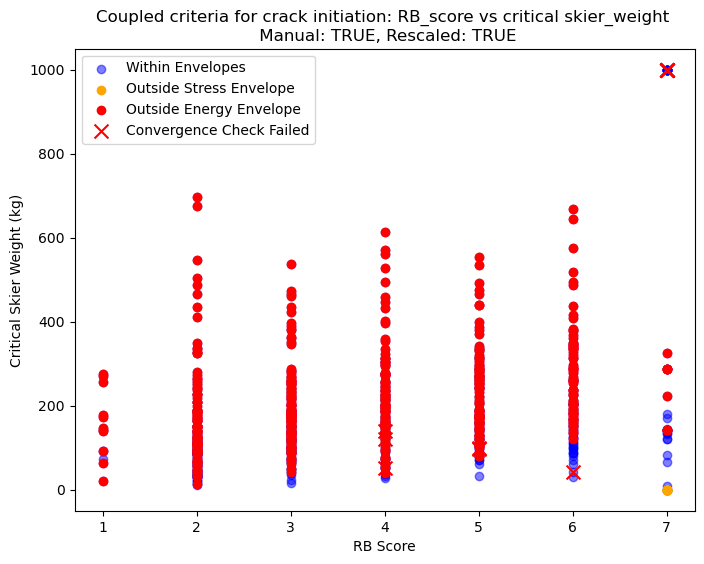

Plot saved to: CN_thesis_plots/applied_criterion_overview/boxplot_critical_skier_weight_by_RB_score_stress_criteria_manual_TRUE_rescaled_TRUE.png


In [45]:
# Define variables for the plot
x_axis = 'RB_score'  # X-axis
y_axis = 'skier_weight'  # Y-axis
descriptor = 'scatter_plot'  # Descriptor for the plot
manual_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
rescaled_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
title = f"Coupled criteria for crack initiation: {x_axis} vs critical {y_axis} \n Manual: {manual_status}, Rescaled: {rescaled_status}"

# Create the scatter plot
plt.figure(figsize=(8, 6))

# Plot all points in blue as the base layer
plt.scatter(df_manual_TRUE_scaled_TRUE[x_axis], df_manual_TRUE_scaled_TRUE[y_axis], color='b', alpha=0.5, label='Within Envelopes')

# Highlight points starting outside the stress envelope in orange
plt.scatter(
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['starting_outside_stress_envelope'] == True, x_axis],
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['starting_outside_stress_envelope'] == True, y_axis],
    color='orange', label='Outside Stress Envelope'
)

# Highlight points starting outside the energy envelope in red
plt.scatter(
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['starting_outside_energy_envelope'] == True, x_axis],
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['starting_outside_energy_envelope'] == True, y_axis],
    color='red', label='Outside Energy Envelope'
)

# Mark points where convergence_check is False with a red cross
plt.scatter(
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['convergence_check'] == False, x_axis],
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['convergence_check'] == False, y_axis],
    color='red', marker='x', s=100, label='Convergence Check Failed'
)

# Add labels, title, and legend
plt.xlabel('RB Score')
plt.ylabel("Critical " + y_axis.replace('_', ' ').title() + " (kg)")
plt.title(title)
plt.legend()

# Save and show the plot
plt.savefig(output_path)
plt.show()

print(f"Plot saved to: {output_path}")

In [ ]:
# When we manually overwrite and rescale the envelope with density, we almost always end up outside the energy envelope for the minimum critical weight

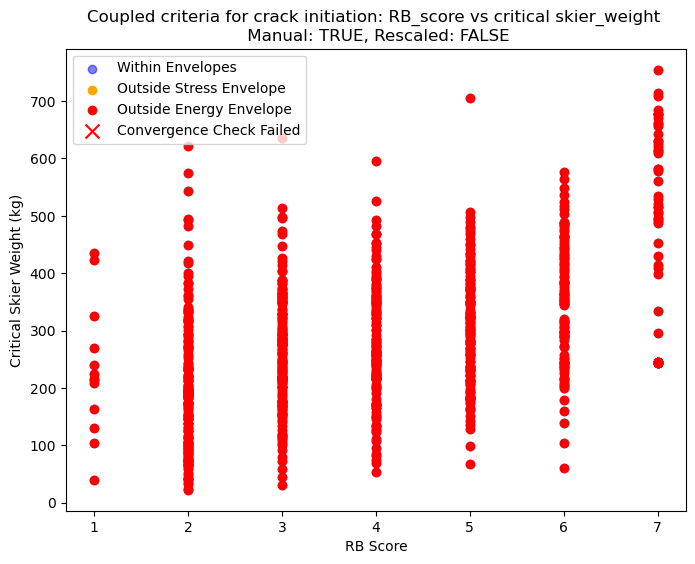

Plot saved to: CN_thesis_plots/applied_criterion_overview/boxplot_critical_skier_weight_by_RB_score_stress_criteria_manual_TRUE_rescaled_TRUE.png


In [48]:
# Define variables for the plot
x_axis = 'RB_score'  # X-axis
y_axis = 'skier_weight'  # Y-axis
descriptor = 'scatter_plot'  # Descriptor for the plot
manual_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
rescaled_status = 'FALSE'  # Replace with 'TRUE' or 'FALSE' based on the data
title = f"Coupled criteria for crack initiation: {x_axis} vs critical {y_axis} \n Manual: {manual_status}, Rescaled: {rescaled_status}"

# Create the scatter plot
plt.figure(figsize=(8, 6))

# Plot all points in blue as the base layer
plt.scatter(df_manual_TRUE_scaled_FALSE[x_axis], df_manual_TRUE_scaled_FALSE[y_axis], color='b', alpha=0.5, label='Within Envelopes')

# Highlight points starting outside the stress envelope in orange
plt.scatter(
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['starting_outside_stress_envelope'] == True, x_axis],
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['starting_outside_stress_envelope'] == True, y_axis],
    color='orange', label='Outside Stress Envelope'
)

# Highlight points starting outside the energy envelope in red
plt.scatter(
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['starting_outside_energy_envelope'] == True, x_axis],
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['starting_outside_energy_envelope'] == True, y_axis],
    color='red', label='Outside Energy Envelope'
)

# Mark points where convergence_check is False with a red cross
plt.scatter(
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['convergence_check'] == False, x_axis],
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['convergence_check'] == False, y_axis],
    color='red', marker='x', s=100, label='Convergence Check Failed'
)

# Add labels, title, and legend
plt.xlabel('RB Score')
plt.ylabel("Critical " + y_axis.replace('_', ' ').title() + " (kg)")
plt.title(title)
plt.legend()

# Save and show the plot
plt.savefig(output_path)
plt.show()

print(f"Plot saved to: {output_path}")

In [ ]:
# If we do not rescale the envelope with weak-layer properties, we always begin outside the energy envelope, and we thus never have convergence issues. 

<Figure size 1000x600 with 0 Axes>

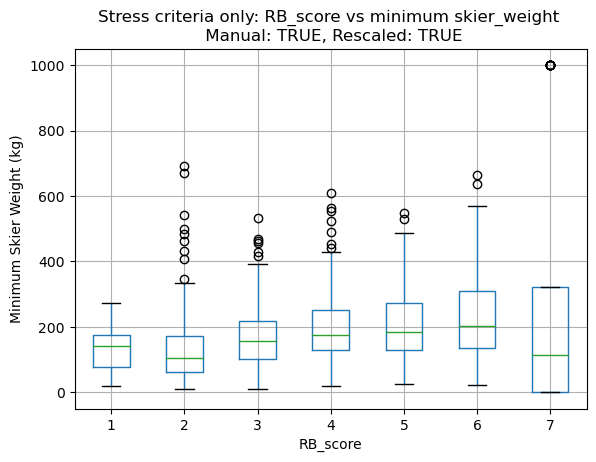

Plot saved to: CN_thesis_plots/applied_criterion_overview/boxplot_critical_skier_weight_by_RB_score_stress_criteria_manual_TRUE_rescaled_TRUE.png


In [49]:
# Define variables for the plot
column = 'critical_skier_weight'  # Y-axis
by = 'RB_score'  # X-axis
descriptor = 'stress_criteria'  # Descriptor for the plot
manual_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
rescaled_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
title = f"Stress criteria only: {x_axis} vs minimum {y_axis} \n Manual: {manual_status}, Rescaled: {rescaled_status}"


# Generate dynamic file name with additional descriptors
file_name = f"boxplot_{column}_by_{by}_{descriptor}_manual_{manual_status}_rescaled_{rescaled_status}.png"
output_path = os.path.join(base_output_dir, file_name)

# Create the plot
plt.figure(figsize=(10, 6))
df_manual_TRUE_scaled_TRUE.boxplot(column=column, by=by)
plt.xlabel(by)
plt.ylabel("Minimum " + y_axis.replace('_', ' ').title() + " (kg)")
plt.title(title)
plt.suptitle('')  # Suppress default title for clarity

# Save and show the plot
plt.savefig(output_path)
plt.show()

print(f"Plot saved to: {output_path}")

<Figure size 1000x600 with 0 Axes>

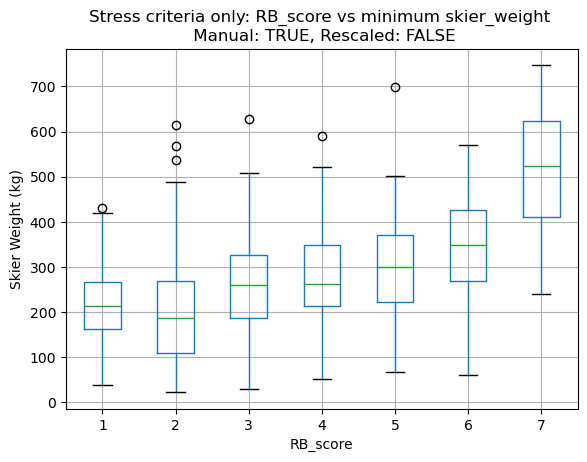

Plot saved to: CN_thesis_plots/applied_criterion_overview/boxplot_critical_skier_weight_by_RB_score_stress_criteria_manual_TRUE_rescaled_FALSE.png


In [41]:
# Define variables for the plot
column = 'critical_skier_weight'  # Y-axis
by = 'RB_score'  # X-axis
descriptor = 'stress_criteria'  # Descriptor for the plot
manual_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
rescaled_status = 'FALSE'  # Replace with 'TRUE' or 'FALSE' based on the data
title = f"Stress criteria only: {x_axis} vs minimum {y_axis} \n Manual: {manual_status}, Rescaled: {rescaled_status}"


# Generate dynamic file name with additional descriptors
file_name = f"boxplot_{column}_by_{by}_{descriptor}_manual_{manual_status}_rescaled_{rescaled_status}.png"
output_path = os.path.join(base_output_dir, file_name)

# Create the plot
plt.figure(figsize=(10, 6))
df_manual_TRUE_scaled_FALSE.boxplot(column=column, by=by)
plt.xlabel(by)
plt.ylabel("Minimum " + y_axis.replace('_', ' ').title() + " (kg)")
plt.title(title)
plt.suptitle('')  # Suppress default title for clarity

# Save and show the plot
plt.savefig(output_path)
plt.show()

print(f"Plot saved to: {output_path}")

<Figure size 1000x600 with 0 Axes>

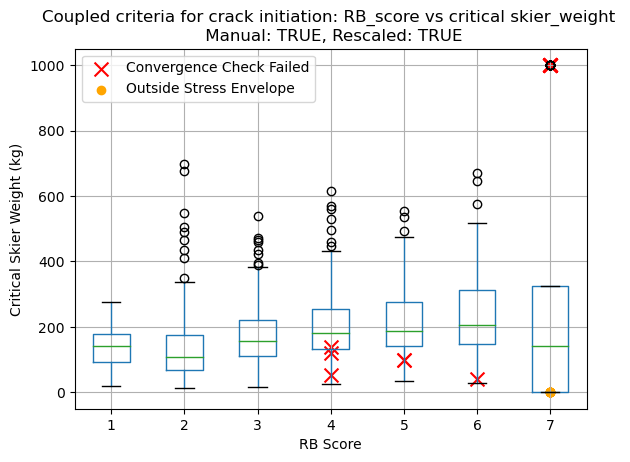

Plot saved to: CN_thesis_plots/applied_criterion_overview/boxplot_skier_weight_by_RB_score_coupled_criteria_manual_TRUE_rescaled_TRUE.png


In [51]:
# Define variables for the plot
column = 'skier_weight'  # Y-axis
by = 'RB_score'  # X-axis
descriptor = 'coupled_criteria'  # Descriptor for the plot
manual_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
rescaled_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
title = f"Coupled criteria for crack initiation: {x_axis} vs critical {y_axis} \n Manual: {manual_status}, Rescaled: {rescaled_status}"


# Generate dynamic file name with additional descriptors
file_name = f"boxplot_{column}_by_{by}_{descriptor}_manual_{manual_status}_rescaled_{rescaled_status}.png"
output_path = os.path.join(base_output_dir, file_name)

# Create the plot
plt.figure(figsize=(10, 6))
df_manual_TRUE_scaled_TRUE.boxplot(column=column, by=by)
plt.xlabel('RB Score')
plt.ylabel("Critical " + y_axis.replace('_', ' ').title() + " (kg)")
plt.title(title)
plt.suptitle('')  # Suppress default title for clarity

# Mark points where convergence_check is False with a red cross
plt.scatter(
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['convergence_check'] == False, by],
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['convergence_check'] == False, column],
    color='red', marker='x', s=100, label='Convergence Check Failed'
)

# Highlight points starting outside the stress envelope in orange
plt.scatter(
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['starting_outside_stress_envelope'] == True, by],
    df_manual_TRUE_scaled_TRUE.loc[df_manual_TRUE_scaled_TRUE['starting_outside_stress_envelope'] == True, column],
    color='orange', label='Outside Stress Envelope'
)

plt.legend()

# Save and show the plot
plt.savefig(output_path)
plt.show()

print(f"Plot saved to: {output_path}")

<Figure size 1000x600 with 0 Axes>

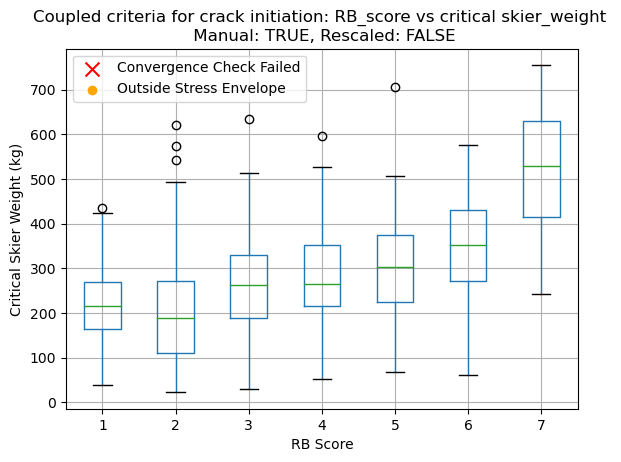

Plot saved to: CN_thesis_plots/applied_criterion_overview/boxplot_skier_weight_by_RB_score_coupled_criteria_manual_TRUE_rescaled_FALSE.png


In [53]:
# Define variables for the plot
column = 'skier_weight'  # Y-axis
by = 'RB_score'  # X-axis
descriptor = 'coupled_criteria'  # Descriptor for the plot
manual_status = 'TRUE'  # Replace with 'TRUE' or 'FALSE' based on the data
rescaled_status = 'FALSE'  # Replace with 'TRUE' or 'FALSE' based on the data
title = f"Coupled criteria for crack initiation: {x_axis} vs critical {y_axis} \n Manual: {manual_status}, Rescaled: {rescaled_status}"


# Generate dynamic file name with additional descriptors
file_name = f"boxplot_{column}_by_{by}_{descriptor}_manual_{manual_status}_rescaled_{rescaled_status}.png"
output_path = os.path.join(base_output_dir, file_name)

# Create the plot
plt.figure(figsize=(10, 6))
df_manual_TRUE_scaled_FALSE.boxplot(column=column, by=by)
plt.xlabel('RB Score')
plt.ylabel("Critical " + y_axis.replace('_', ' ').title() + " (kg)")
plt.title(title)
plt.suptitle('')  # Suppress default title for clarity

# Mark points where convergence_check is False with a red cross
plt.scatter(
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['convergence_check'] == False, by],
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['convergence_check'] == False, column],
    color='red', marker='x', s=100, label='Convergence Check Failed'
)

# Highlight points starting outside the stress envelope in orange
plt.scatter(
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['starting_outside_stress_envelope'] == True, by],
    df_manual_TRUE_scaled_FALSE.loc[df_manual_TRUE_scaled_FALSE['starting_outside_stress_envelope'] == True, column],
    color='orange', label='Outside Stress Envelope'
)

plt.legend()

# Save and show the plot
plt.savefig(output_path)
plt.show()

print(f"Plot saved to: {output_path}")